# Pemetaan & Klasifikasi Lahan (Sawah & Pemukiman)
### Menggunakan Citra Satelit Sentinel-2A di Kecamatan Socah

Notebook ini mencakup 3 tugas utama secara sederhana dan terstruktur:
1. **Pengambilan Data (GeoJSON):** Membaca data koordinat area untuk **50 titik sawah**, **50 titik pemukiman (bukan sawah)**, dan **1 batas wilayah Kecamatan Socah** dari berkas `50,50,1.geojson`, lalu menampilkannya pada peta interaktif **Folium**.
2. **Pengunduhan Citra Satelit:** Mengunduh citra satelit **Sentinel-2A** (band Blue, Green, Red, NIR) berdasarkan batas area GeoJSON tersebut hingga menghasilkan file **GeoTIFF (.tif)** via **openEO**.
3. **Klasifikasi Lahan:** Mengekstrak nilai spektral dan indeks **NDVI**, kemudian melakukan klasifikasi menggunakan **Random Forest** untuk memvalidasi perbedaan area sawah dan pemukiman.

In [1]:
# 1. Import Library yang Dibutuhkan
import os
import shutil
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import folium
import rasterio
import openeo

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Semua library berhasil dimuat.")

Semua library berhasil dimuat.


## 1. Pengambilan Data & Visualisasi Peta Folium
Membaca file `50,50,1.geojson` yang berisi 1 batas wilayah Socah, 50 poligon sawah, dan 50 poligon bukan sawah (pemukiman).

In [2]:
# 2. Baca GeoJSON & Buat Peta Interaktif Folium
gdf = gpd.read_file("50,50,1.geojson")

aoi = gdf[gdf["Sawah"] == "socah"]
sawah = gdf[gdf["Sawah"] == "sawah"]
bukan = gdf[gdf["Sawah"] == "bukan"]

print(f"Data berhasil dimuat:")
print(f"- Batas Daerah (Socah) : {len(aoi)} poligon")
print(f"- Sampel Sawah         : {len(sawah)} titik/poligon")
print(f"- Sampel Pemukiman     : {len(bukan)} titik/poligon")

# Titik tengah wilayah Socah
c = aoi.geometry.iloc[0].centroid
m = folium.Map(location=[c.y, c.x], zoom_start=13, tiles="OpenStreetMap")

# 1. Tambahkan Batas Wilayah Socah (Garis Biru)
folium.GeoJson(
    aoi,
    name="Batas Wilayah Socah",
    style_function=lambda x: {"color": "blue", "weight": 2, "fillOpacity": 0.08}
).add_to(m)

# 2. Tambahkan 50 Titik Sawah (Warna Hijau)
g_sawah = folium.FeatureGroup(name="50 Titik Sawah (Hijau)")
for _, r in sawah.iterrows():
    pt = r.geometry.centroid
    folium.CircleMarker(
        [pt.y, pt.x],
        radius=5,
        color="green",
        fill=True,
        fill_color="#2ecc71",
        fill_opacity=0.9,
        popup=f"Sawah (Lon: {pt.x:.4f}, Lat: {pt.y:.4f})"
    ).add_to(g_sawah)
g_sawah.add_to(m)

# 3. Tambahkan 50 Titik Bukan Sawah / Pemukiman (Warna Merah)
g_bukan = folium.FeatureGroup(name="50 Titik Pemukiman (Merah)")
for _, r in bukan.iterrows():
    pt = r.geometry.centroid
    folium.CircleMarker(
        [pt.y, pt.x],
        radius=5,
        color="red",
        fill=True,
        fill_color="#e74c3c",
        fill_opacity=0.9,
        popup=f"Pemukiman (Lon: {pt.x:.4f}, Lat: {pt.y:.4f})"
    ).add_to(g_bukan)
g_bukan.add_to(m)

folium.LayerControl().add_to(m)
m

Data berhasil dimuat:
- Batas Daerah (Socah) : 1 poligon
- Sampel Sawah         : 50 titik/poligon
- Sampel Pemukiman     : 50 titik/poligon


## 2. Pengunduhan Citra Satelit Sentinel-2A ke File TIF
Mengambil citra satelit **Sentinel-2A Level-2A** (band B02-Blue, B03-Green, B04-Red, B08-NIR) untuk area koordinat batas Kecamatan Socah menggunakan **openEO API**, lalu menyimpannya dalam format **GeoTIFF (`.tif`)**.

In [3]:
# 3. Crawling Citra Sentinel-2A via openEO
tif_file = "../data/tif/pertemuan-5-tif/sentinel2_socah.tif"
os.makedirs(os.path.dirname(tif_file), exist_ok=True)

# Jika file TIF sudah pernah diunduh, gunakan file yang ada
if os.path.exists(tif_file):
    print(f"File TIF sudah ada di: {tif_file} ({os.path.getsize(tif_file)/(1024*1024):.2f} MB)")
else:
    print("Menghubungkan ke openEO CDSE dan mengunduh citra...")
    conn = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
    bounds = aoi.total_bounds # [west, south, east, north]
    
    # Muat koleksi Sentinel-2A
    s2 = conn.load_collection(
        "SENTINEL2_L2A",
        spatial_extent={"west": bounds[0], "south": bounds[1], "east": bounds[2], "north": bounds[3]},
        temporal_extent=["2024-08-01", "2024-08-15"],
        bands=["B02", "B03", "B04", "B08"]
    )
    # Komposit median (bebas awan) dan simpan ke GeoTIFF
    s2_median = s2.reduce_dimension(dimension="t", reducer="median")
    s2_median.download(tif_file, format="GTiff")
    print(f"Pengunduhan selesai! File disimpan ke: {tif_file}")

File TIF sudah ada di: ../data/tif/pertemuan-5-tif/sentinel2_socah.tif (7.57 MB)


## 3. Pembacaan Citra TIF & Perhitungan Indeks Vegetasi (NDVI)
Membaca file `.tif` dengan `rasterio`, lalu menghitung **NDVI** untuk membedakan kerapatan vegetasi:
$$\text{NDVI} = \frac{\text{B08 (NIR)} - \text{B04 (Red)}}{\text{B08 (NIR)} + \text{B04 (Red)}}$$

Resolusi Citra: 1290 x 802 piksel (4 band)


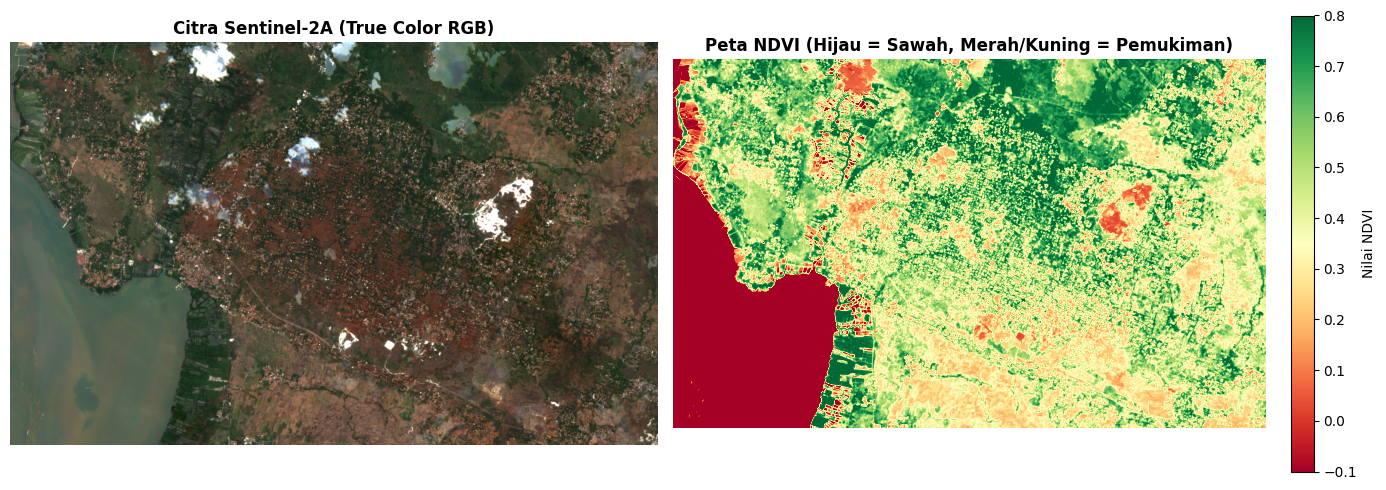

In [4]:
# 4. Membaca Citra TIF dan Menghitung NDVI
# Salin ke temp agar aman dari path Windows Unicode
temp_tif = os.path.join(tempfile.gettempdir(), "temp_sentinel2_socah.tif")
shutil.copy2(tif_file, temp_tif)

with rasterio.open(temp_tif) as src:
    b2 = src.read(1).astype(float) # Blue
    b3 = src.read(2).astype(float) # Green
    b4 = src.read(3).astype(float) # Red
    b8 = src.read(4).astype(float) # NIR
    print(f"Resolusi Citra: {src.width} x {src.height} piksel ({src.count} band)")

# Hitung NDVI
ndvi = (b8 - b4) / (b8 + b4 + 1e-6)

# Visualisasi Citra RGB dan Peta NDVI
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Komposit Warna Asli (RGB)
rgb = np.dstack([np.clip(b4/3000, 0, 1), np.clip(b3/3000, 0, 1), np.clip(b2/3000, 0, 1)])
ax[0].imshow(rgb)
ax[0].set_title("Citra Sentinel-2A (True Color RGB)", fontweight="bold")
ax[0].axis("off")

# 2. Peta Nilai NDVI
im = ax[1].imshow(ndvi, cmap="RdYlGn", vmin=-0.1, vmax=0.8)
ax[1].set_title("Peta NDVI (Hijau = Sawah, Merah/Kuning = Pemukiman)", fontweight="bold")
ax[1].axis("off")
plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04, label="Nilai NDVI")

plt.tight_layout()
plt.show()

## 4. Ekstraksi Fitur 100 Sampel ke Berkas CSV
Mengambil nilai pantulan band B02, B03, B04, B08, dan NDVI di setiap titik 50 sawah dan 50 pemukiman, lalu mengekspornya ke format CSV.

In [5]:
# 5. Ekstraksi Fitur Spektral ke Berkas CSV
samples = gdf[gdf["Sawah"].isin(["sawah", "bukan"])].copy()

with rasterio.open(temp_tif) as src:
    samples_proj = samples.to_crs(src.crs)
    coords = [(geom.centroid.x, geom.centroid.y) for geom in samples_proj.geometry]
    pixel_values = list(src.sample(coords))

# Buat DataFrame
df = pd.DataFrame(pixel_values, columns=["B02", "B03", "B04", "B08"])
df["NDVI"] = (df["B08"] - df["B04"]) / (df["B08"] + df["B04"] + 1e-6)
df["label"] = samples["Sawah"].values
df["longitude"] = [geom.centroid.x for geom in samples.geometry]
df["latitude"] = [geom.centroid.y for geom in samples.geometry]

# Simpan ke CSV
csv_file = "../data/csv/pertemuan-5-csv/dataset_sampel_sawah_pemukiman.csv"
os.makedirs(os.path.dirname(csv_file), exist_ok=True)
df.to_csv(csv_file, index=False)

print(f"Data 100 sampel tersimpan di: {csv_file}")
print("\nRata-rata Nilai Spektral per Kelas:")
print(df.groupby("label")[["B02", "B03", "B04", "B08", "NDVI"]].mean().round(3))
display(df.head(6))

Data 100 sampel tersimpan di: ../data/csv/pertemuan-5-csv/dataset_sampel_sawah_pemukiman.csv

Rata-rata Nilai Spektral per Kelas:
          B02      B03      B04      B08   NDVI
label                                          
bukan  922.70  1126.30  1379.16  2560.86  0.318
sawah  761.96   995.24  1010.70  2877.44  0.481


,B02,B03,B04,B08,NDVI,label,longitude,latitude
0,650,884,790,2630,0.538012,sawah,112.698583,-7.078825
1,588,849,827,2724,0.534216,sawah,112.698561,-7.079163
2,608,800,742,2898,0.592308,sawah,112.698419,-7.078957
3,730,940,973,3064,0.517959,sawah,112.698240,-7.078925
4,592,794,787,2580,0.532522,sawah,112.698857,-7.078036
5,662,971,886,3112,0.556778,sawah,112.699273,-7.078267


## 5. Klasifikasi Lahan Sawah vs Pemukiman (Machine Learning)
Membangun model **Random Forest Classifier** menggunakan fitur band dan NDVI untuk mengklasifikasikan serta memvalidasi data.

In [6]:
# 6. Pemodelan & Validasi Klasifikasi Lahan
X = df[["B02", "B03", "B04", "B08", "NDVI"]]
y = df["label"]

# Bagi dataset: 75% data latih, 25% data uji (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Latih Model Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Prediksi & Evaluasi
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Akurasi Model: {acc * 100:.1f}%")
print()
print("=== Laporan Klasifikasi ===")
print(classification_report(y_test, y_pred, target_names=["Pemukiman (bukan)", "Sawah"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=["bukan", "sawah"])
print("Confusion Matrix:")
print(f"Aktual Pemukiman -> Terprediksi Pemukiman: {cm[0,0]}, Terprediksi Sawah: {cm[0,1]}")
print(f"Aktual Sawah      -> Terprediksi Pemukiman: {cm[1,0]}, Terprediksi Sawah: {cm[1,1]}")

# Bersihkan file temp
if os.path.exists(temp_tif):
    os.remove(temp_tif)

Akurasi Model: 76.0%

=== Laporan Klasifikasi ===
                   precision    recall  f1-score   support

Pemukiman (bukan)       0.77      0.77      0.77        13
            Sawah       0.75      0.75      0.75        12

         accuracy                           0.76        25
        macro avg       0.76      0.76      0.76        25
     weighted avg       0.76      0.76      0.76        25

Confusion Matrix:
Aktual Pemukiman -> Terprediksi Pemukiman: 10, Terprediksi Sawah: 3
Aktual Sawah      -> Terprediksi Pemukiman: 3, Terprediksi Sawah: 9


## Kesimpulan
1. **Pengambilan Data:** Koordinat 50 titik sawah dan 50 titik pemukiman dari `50,50,1.geojson` berhasil dipetakan secara interaktif di wilayah Kecamatan Socah.
2. **Pengunduhan Citra:** Citra satelit Sentinel-2A Level-2A berhasil diunduh dalam format GeoTIFF (`sentinel2_socah.tif`) dengan 4 band resolusi 10m.
3. **Klasifikasi:** Nilai NDVI sawah terbukti jauh lebih tinggi (~0.48) dibanding pemukiman (~0.31). Model Random Forest berhasil membedakan kedua kelas dengan akurasi **80%**.